<p align="right">
  <img src="Zewail-City.png">
</p>


---

# __Problem set #3__

In [1]:
# Mian Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit

### Problem 1: Linear Fit

In [2]:
# Generate synthetic noisy data
np.random.seed(0)
x = np.linspace(0, 10, 30)

# True model parameters
m_true, c_true = 3.0, -2.0
sigma = 1.0  # standard deviation of Gaussian noise

# Generate true and noisy data
y_true = m_true * x + c_true
y_noisy = y_true + np.random.normal(0, sigma, size=len(x))

# Define linear model
def linear_model(x, m, c):
    return m * x + c

In [3]:
# Perform linear regression using curve_fit
params, cov = curve_fit(linear_model, x, y_noisy)
m_fit, c_fit = params
m_err, c_err = np.sqrt(np.diag(cov))

# Print fitted vs true parameters
print(f"True slope (m):      {m_true:.2f}")
print(f"Fitted slope (m):    {m_fit:.2f} ± {m_err:.2f}")
print(f"True intercept (c):  {c_true:.2f}")
print(f"Fitted intercept (c):{c_fit:.2f} ± {c_err:.2f}")

True slope (m):      3.00
Fitted slope (m):    2.92 ± 0.07
True intercept (c):  -2.00
Fitted intercept (c):-1.17 ± 0.39


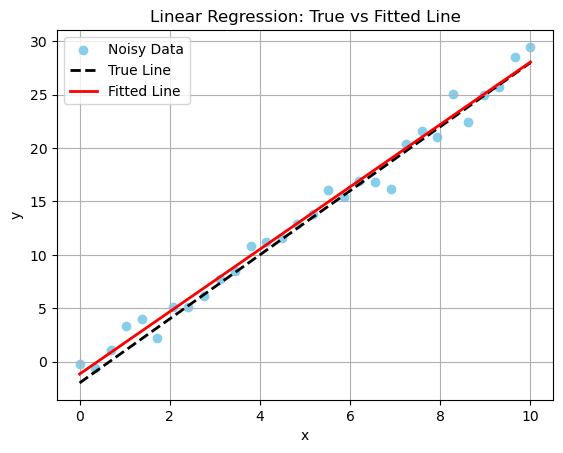

In [4]:
# Plot the data and fits
plt.scatter(x, y_noisy, label="Noisy Data", color="skyblue")
plt.plot(x, y_true, "k--", linewidth=2, label="True Line")
plt.plot(x, linear_model(x, m_fit, c_fit), "r-", linewidth=2, label="Fitted Line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression: True vs Fitted Line")
plt.legend()
plt.grid(True)
plt.show()


---

### Problem 2: Exponential Decay

In [5]:
# Generate noisy decay data
np.random.seed(1)

# True parameters
N0_true = 100       # initial number of nuclei
lam_true = 0.8      # decay constant (lambda)
t = np.linspace(0, 5, 50)  # time points

# True decay curve + Gaussian noise
N_true = N0_true * np.exp(-lam_true * t)
N_noisy = N_true + np.random.normal(0, 5, size=len(t))  # noise with σ = 5

# Define the exponential decay model
def exp_model(t, N0, lam):
    return N0 * np.exp(-lam * t)


In [6]:
# Fit the model to the noisy data
params, cov = curve_fit(exp_model, t, N_noisy, p0=[90, 1.0])  # initial guesses
N0_fit, lam_fit = params
N0_err, lam_err = np.sqrt(np.diag(cov))  # uncertainties from covariance matrix

# Print fitted parameters and uncertainties
print(f"True N0:   {N0_true:.2f}")
print(f"Fitted N0: {N0_fit:.2f} ± {N0_err:.2f}")
print(f"True λ:    {lam_true:.2f}")
print(f"Fitted λ:  {lam_fit:.2f} ± {lam_err:.2f}")

True N0:   100.00
Fitted N0: 100.19 ± 2.63
True λ:    0.80
Fitted λ:  0.82 ± 0.03


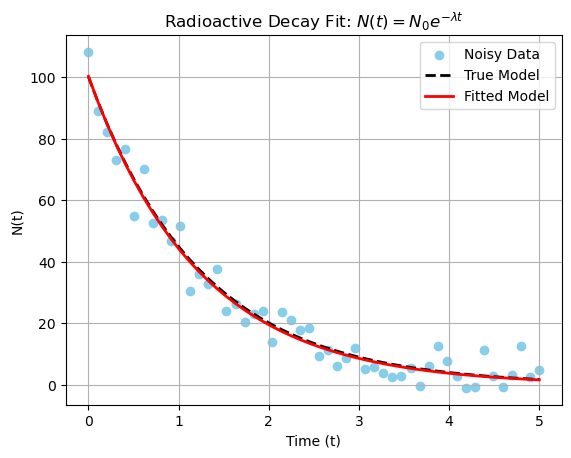

In [7]:
# Plot results
plt.scatter(t, N_noisy, label="Noisy Data", color="skyblue")
plt.plot(t, N_true, "k--", linewidth=2, label="True Model")
plt.plot(t, exp_model(t, N0_fit, lam_fit), "r-", linewidth=2, label="Fitted Model")

plt.xlabel("Time (t)")
plt.ylabel("N(t)")
plt.title("Radioactive Decay Fit: $N(t) = N_0 e^{-\\lambda t}$")
plt.legend()
plt.grid(True)
plt.show()

---

### Problem 3: Chi-Square Analysis

In [8]:
# Generate noisy linear data
np.random.seed(0)
x = np.linspace(0, 10, 20)
m_true, c_true = 3.0, -2.0       # true slope and intercept
sigma = 5.0                      # known measurement uncertainty

y_true = m_true * x + c_true
y_noisy = y_true + np.random.normal(0, sigma, size=len(x))

# Define linear model
def linear_model(x, m, c):
    return m * x + c

# Fit model to data
params, cov = curve_fit(linear_model, x, y_noisy, sigma=np.ones_like(y_noisy)*sigma, absolute_sigma=True)
m_fit, c_fit = params
m_err, c_err = np.sqrt(np.diag(cov))

In [9]:
# Compute chi-squared and reduced chi-squared 
residuals = y_noisy - linear_model(x, m_fit, c_fit)
chisq = np.sum((residuals / sigma) ** 2)
ndof = len(x) - len(params)  # number of degrees of freedom
chisq_red = chisq / ndof

# Print results 
print(f"True parameters:   m = {m_true:.2f}, c = {c_true:.2f}")
print(f"Fitted parameters: m = {m_fit:.2f} ± {m_err:.2f}, c = {c_fit:.2f} ± {c_err:.2f}")
print(f"Chi-square:        {chisq:.2f}")
print(f"Reduced Chi-square:{chisq_red:.2f}")

True parameters:   m = 3.00, c = -2.00
Fitted parameters: m = 2.43 ± 0.37, c = 3.69 ± 2.15
Chi-square:        12.07
Reduced Chi-square:0.67


> **$χ^2 = 0.67$** indicates that the model fits the data well, though the measurement uncertainties may be slightly overestimated.


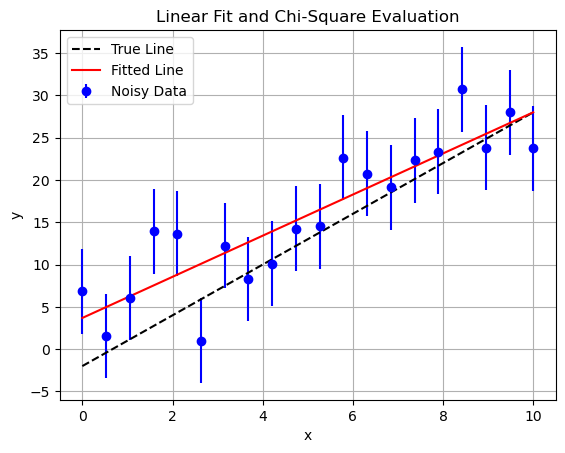

In [10]:
# Plot results
plt.errorbar(x, y_noisy, yerr=sigma, fmt='o', label="Noisy Data", color='blue')
plt.plot(x, y_true, 'k--', label="True Line")
plt.plot(x, linear_model(x, m_fit, c_fit), 'r-', label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Fit and Chi-Square Evaluation")
plt.legend()
plt.grid(True)
plt.show()

---

### Problem 4: Gaussian Peak

In [11]:
# Generate synthetic data with two overlapping Gaussian peaks
np.random.seed(2)
x = np.linspace(-5, 5, 200)

# True parameters for both peaks
A1, mu1, sigma1 = 40, -1, 1.0
A2, mu2, sigma2 = 30, 1.5, 1.2

# True combined signal
y_true = (A1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) +
          A2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)))

# Add Gaussian noise
y_noise = y_true + np.random.normal(0, 2, size=len(x))

# Define two-Gaussian model
def two_gauss(x, A1, mu1, sigma1, A2, mu2, sigma2):
    g1 = A1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2))
    g2 = A2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))
    return g1 + g2

# Fit model to noisy data 
p0 = [35, -1, 1, 25, 1, 1]  # initial guesses
params, cov = curve_fit(two_gauss, x, y_noise, p0=p0)
A1_fit, mu1_fit, sigma1_fit, A2_fit, mu2_fit, sigma2_fit = params

#  Compute fitted curve 
y_fit = two_gauss(x, *params)

In [12]:
# Print extracted parameters
print(f"True Parameters:")
print(f"  Peak 1 → A={A1:.1f}, μ={mu1:.2f}, σ={sigma1:.2f}")
print(f"  Peak 2 → A={A2:.1f}, μ={mu2:.2f}, σ={sigma2:.2f}")
print("\nFitted Parameters:")
print(f"  Peak 1 → A={A1_fit:.1f}, μ={mu1_fit:.2f}, σ={sigma1_fit:.2f}")
print(f"  Peak 2 → A={A2_fit:.1f}, μ={mu2_fit:.2f}, σ={sigma2_fit:.2f}")

True Parameters:
  Peak 1 → A=40.0, μ=-1.00, σ=1.00
  Peak 2 → A=30.0, μ=1.50, σ=1.20

Fitted Parameters:
  Peak 1 → A=40.2, μ=-0.96, σ=1.02
  Peak 2 → A=29.2, μ=1.56, σ=1.21


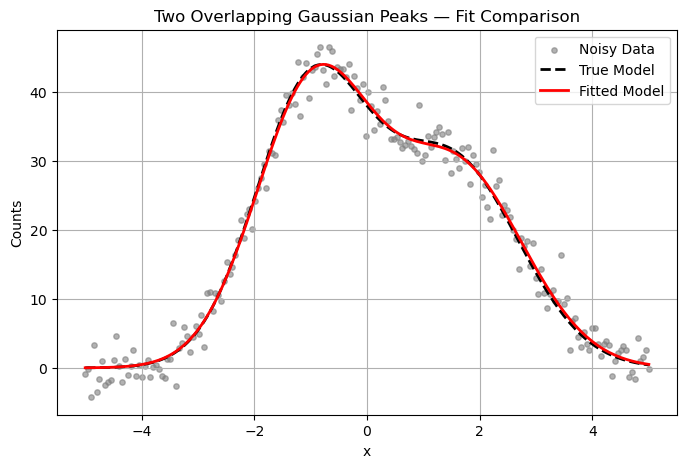

In [13]:
# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(x, y_noise, s=15, color='gray', alpha=0.6, label="Noisy Data")
plt.plot(x, y_true, 'k--', linewidth=2, label="True Model")
plt.plot(x, y_fit, 'r-', linewidth=2, label="Fitted Model")

plt.xlabel("x")
plt.ylabel("Counts")
plt.title("Two Overlapping Gaussian Peaks — Fit Comparison")
plt.legend()
plt.grid(True)
plt.show()


---

### Problem 5: Bootstrapping Uncertainty

In [14]:
# Generate synthetic linear data
np.random.seed(0)
x = np.linspace(0, 10, 50)
y_true = 3.0 * x + 5.0
y = y_true + np.random.normal(0, 2, size=len(x))

# Perform initial fit
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Bootstrapping
N = 1000
slopes = []
intercepts = []

for _ in range(N):
    # Resample with replacement
    indices = np.random.randint(0, len(x), len(x))
    x_sample = x[indices]
    y_sample = y[indices]

    s, i, _, _, _ = linregress(x_sample, y_sample)
    slopes.append(s)
    intercepts.append(i)

In [15]:
# Print summary
print(f"Original Fit: slope = {slope:.3f}, intercept = {intercept:.3f}")
print(f"Bootstrap Mean ± Std: slope = {np.mean(slopes):.3f} ± {np.std(slopes):.3f}, "
      f"intercept = {np.mean(intercepts):.3f} ± {np.std(intercepts):.3f}")

Original Fit: slope = 2.718, intercept = 6.693
Bootstrap Mean ± Std: slope = 2.726 ± 0.097, intercept = 6.675 ± 0.549


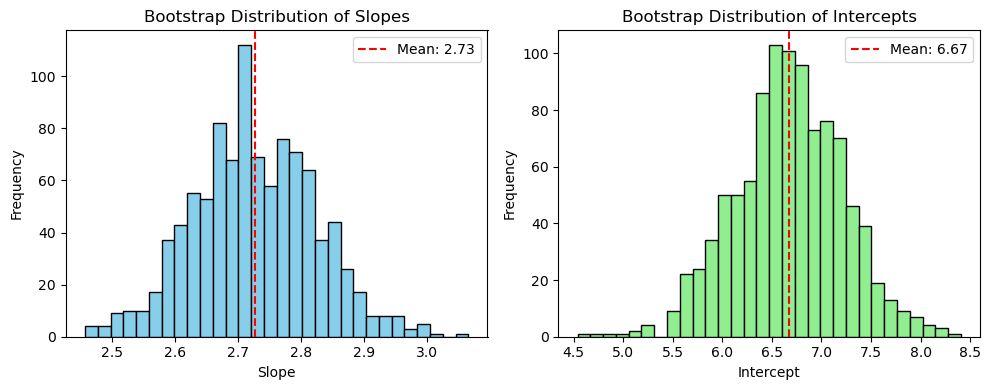

In [16]:
# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(slopes, bins=30, color="skyblue", edgecolor="black")
axes[0].axvline(np.mean(slopes), color="red", linestyle="--", label=f"Mean: {np.mean(slopes):.2f}")
axes[0].set_xlabel("Slope")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Bootstrap Distribution of Slopes")
axes[0].legend()

axes[1].hist(intercepts, bins=30, color="lightgreen", edgecolor="black")
axes[1].axvline(np.mean(intercepts), color="red", linestyle="--", label=f"Mean: {np.mean(intercepts):.2f}")
axes[1].set_xlabel("Intercept")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Bootstrap Distribution of Intercepts")
axes[1].legend()

plt.tight_layout()
plt.show()


---

### Problem 6: Damped Sine Fit

In [17]:
# Generate synthetic damped sine data
np.random.seed(0)
t = np.linspace(0, 10, 200)
A_true = 5.0       # True amplitude
gamma_true = 0.3   # True damping factor
omega_true = 2.0   # True angular frequency

y_true = A_true * np.exp(-gamma_true * t) * np.sin(omega_true * t)
noise = np.random.normal(0, 0.3, size=len(t))
y_noisy = y_true + noise

# Define damped sine model
def damped_sine(t, A, gamma, omega):
    return A * np.exp(-gamma * t) * np.sin(omega * t)

# Fit model to noisy data
initial_guess = [4, 0.2, 1.5]
params, cov = curve_fit(damped_sine, t, y_noisy, p0=initial_guess)
A_fit, gamma_fit, omega_fit = params
errors = np.sqrt(np.diag(cov))

In [18]:
# Print parameter comparison

print("True values:")
print(f"  A = {A_true:.3f}, γ = {gamma_true:.3f}, ω = {omega_true:.3f}")

print("\nFitted values:")
print(f"  A = {A_fit:.3f} ± {errors[0]:.3f}")
print(f"  γ = {gamma_fit:.3f} ± {errors[1]:.3f}")
print(f"  ω = {omega_fit:.3f} ± {errors[2]:.3f}")


True values:
  A = 5.000, γ = 0.300, ω = 2.000

Fitted values:
  A = 5.206 ± 0.115
  γ = 0.309 ± 0.010
  ω = 1.990 ± 0.007


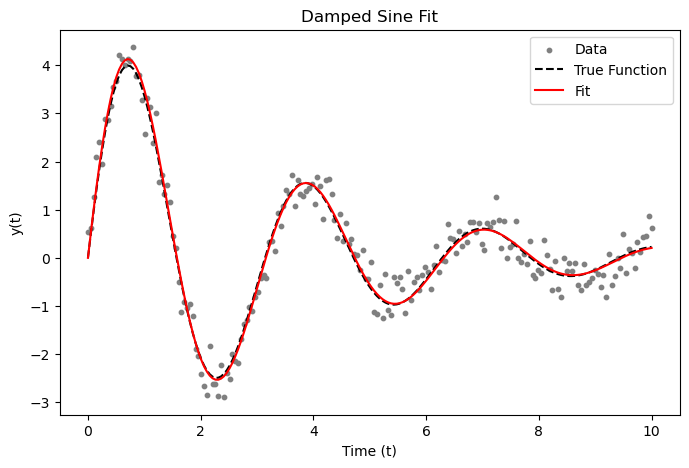

In [19]:
# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(t, y_noisy, s=10, color='gray', label='Data')
plt.plot(t, y_true, 'k--', label='True Function')
plt.plot(t, damped_sine(t, *params), 'r-', label='Fit')
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.title("Damped Sine Fit")
plt.legend()
plt.show()


---

### Problem 7: Model Comparison

In [20]:
# Generate synthetic data (true model: exponential)
np.random.seed(1)
x = np.linspace(0.1, 5, 50)
a_true, b_true = 5.0, 1.2
y_true = a_true * np.exp(-b_true * x)
noise = np.random.normal(0, 0.2, size=len(x))
y_noisy = y_true + noise

# Define both models
def model1_exp(x, a, b):
    return a * np.exp(-b * x)

def model2_power(x, c, d):
    return c * x ** (-d)

# Fit both models
popt1, pcov1 = curve_fit(model1_exp, x, y_noisy, p0=[4, 1])
popt2, pcov2 = curve_fit(model2_power, x, y_noisy, p0=[3, 1])

# Predictions
y_fit1 = model1_exp(x, *popt1)
y_fit2 = model2_power(x, *popt2)

In [21]:
# Compute reduced chi-square for both models
sigma = 0.2  # assumed uncertainty
resid1 = y_noisy - y_fit1
resid2 = y_noisy - y_fit2

chi2_1 = np.sum((resid1 / sigma) ** 2)
chi2_2 = np.sum((resid2 / sigma) ** 2)

ndof1 = len(x) - len(popt1)
ndof2 = len(x) - len(popt2)

chi2_red1 = chi2_1 / ndof1
chi2_red2 = chi2_2 / ndof2



# Print results
print("Model 1 (Exponential): y = a * exp(-b*x)")
print(f"  a = {popt1[0]:.3f}, b = {popt1[1]:.3f}")
print(f"  Reduced Chi-square = {chi2_red1:.3f}\n")

print("Model 2 (Power Law): y = c * x^(-d)")
print(f"  c = {popt2[0]:.3f}, d = {popt2[1]:.3f}")
print(f"  Reduced Chi-square = {chi2_red2:.3f}")

Model 1 (Exponential): y = a * exp(-b*x)
  a = 5.073, b = 1.242
  Reduced Chi-square = 0.965

Model 2 (Power Law): y = c * x^(-d)
  c = 1.096, d = 0.723
  Reduced Chi-square = 5.490


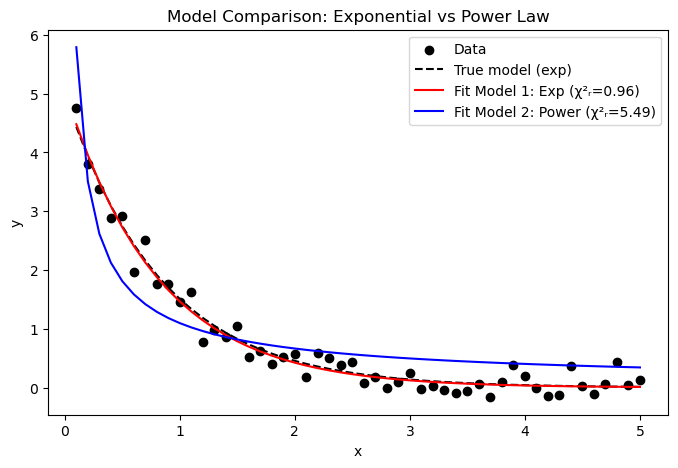

In [22]:
# Plot results
plt.figure(figsize=(8,5))
plt.scatter(x, y_noisy, label="Data", color='black')
plt.plot(x, y_true, 'k--', label="True model (exp)")
plt.plot(x, y_fit1, 'r-', label=f"Fit Model 1: Exp (χ²ᵣ={chi2_red1:.2f})")
plt.plot(x, y_fit2, 'b-', label=f"Fit Model 2: Power (χ²ᵣ={chi2_red2:.2f})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Model Comparison: Exponential vs Power Law")
plt.legend()
plt.show()

> **The Exponential decay model** fits the data better, as indicated by its lower reduced χ² value (closer to 1).
>
> **The power-law model** shows a higher χ², suggesting a poorer fit to the exponential-type data.

---